In [4]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Define class names early so they are available for all visualizations
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

## Datan lataus ja esikäsittely
Ladataan data ja skaalataan pikseliarvot välille 0-1. Muutetaan myös luokkamuuttujat one-hot-koodattuun muotoon.

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Mallin arkkitehtuuri
FCN vaatii kuvadatan litistämisen (Flatten) 1D-muotoon. Koska 32x32x3 kuvasta tulee 3072 syöteparametria, verkkoon syntyy valtava määrä painoja. Käytämme Batch Normalization ja Dropout -tekniikoita ylisovittamisen (overfitting) estämiseksi.

In [6]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)

x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,710,346 (6.52 MB)

 Trainable params: 1,708,810 (6.52 MB)

 Non-trainable params: 1,536 (6.00 KB)

## Mallin kääntäminen ja opetus
Käytämme hieman pienempää oppimisnopeutta (learning rate) FCN-mallin vakauttamiseksi.

In [7]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.2578 - loss: 2.4066 - val_accuracy: 0.3743 - val_loss: 1.7522
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3361 - loss: 1.9154 - val_accuracy: 0.3127 - val_loss: 1.9300
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3716 - loss: 1.7879 - val_accuracy: 0.3452 - val_loss: 1.8102
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3904 - loss: 1.7140 - val_accuracy: 0.4165 - val_loss: 1.6476
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4082 - loss: 1.6631 - val_accuracy: 0.4181 - val_loss: 1.6181
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4163 - loss: 1.6453 - val_accuracy: 0.4106 - val_loss: 1.6540
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4198 - loss: 1.6385 - val_accuracy: 0.4285 - val_loss: 1.6063
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4222 - loss: 1.6242 - val_accu

## Arviointi ja oppimiskäyrien visualisointi
Vertaillaan opetus- ja validointidatan häviötä (loss) sekä tarkkuutta (accuracy).

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4761 - loss: 1.4605
Test accuracy: 0.4748


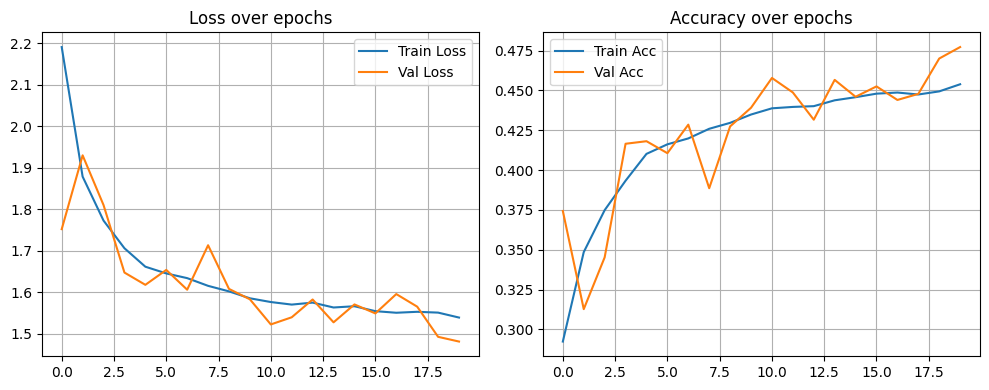

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss over epochs")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy over epochs")
plt.grid(True)

plt.tight_layout()
plt.show()

## Luokkien todennäköisyysjakauma (Class Probability Distribution)
Tarkastellaan yksittäisen kuvan kohdalla, kuinka varma malli on ennusteestaan visualisoimalla softmax-kerroksen ulostulo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


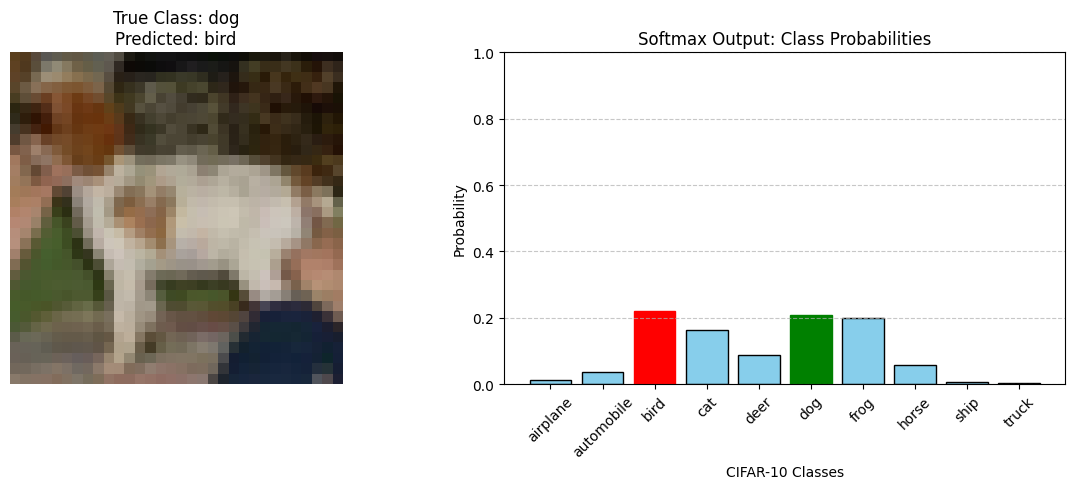

In [9]:
img_index = 12
test_image = x_test[img_index]
true_label_index = np.argmax(y_test[img_index])

prediction_batch = model.predict(np.expand_dims(test_image, axis=0))
prediction_probs = prediction_batch[0]
predicted_label_index = np.argmax(prediction_probs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title(f"True Class: {class_names[true_label_index]}\nPredicted: {class_names[predicted_label_index]}")
plt.axis("off")

plt.subplot(1, 2, 2)
bars = plt.bar(class_names, prediction_probs, color='skyblue', edgecolor='black')

if predicted_label_index == true_label_index:
    bars[predicted_label_index].set_color('green')
else:
    bars[predicted_label_index].set_color('red')
    bars[true_label_index].set_color('green')

plt.title("Softmax Output: Class Probabilities")
plt.xlabel("CIFAR-10 Classes")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.ylim([0, 1]) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Väärin luokitellut kuvat
Analysoidaan kuvia, joita malli ei onnistunut tunnistamaan oikein. FCN-mallilla on tyypillisesti vaikeuksia erottaa taustaa kohteesta.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


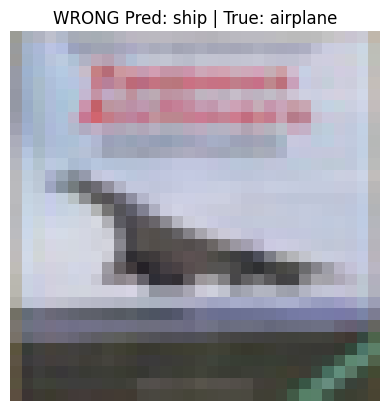

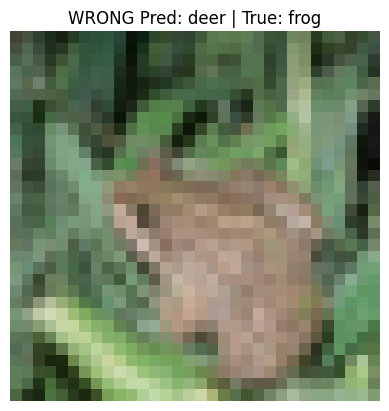

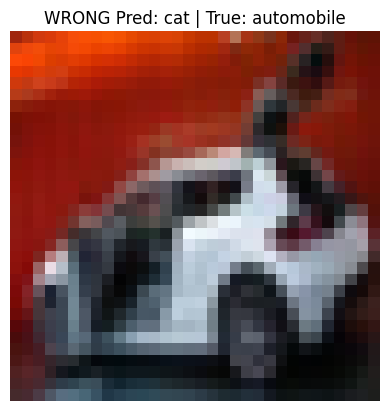

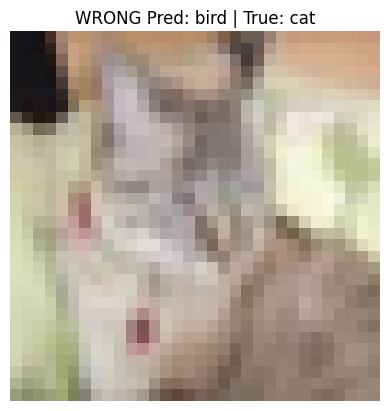

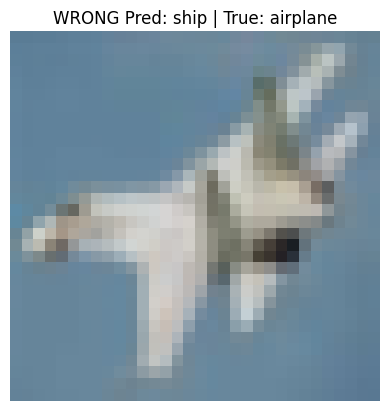

In [10]:
predictions = model.predict(x_test)
wrong_indices = np.where(
    np.argmax(predictions, axis=1) != np.argmax(y_test, axis=1)
)[0]

for i in wrong_indices[:5]:
    plt.imshow(x_test[i])
    pred = np.argmax(predictions[i])
    true = np.argmax(y_test[i])
    plt.title(f"WRONG Pred: {class_names[pred]} | True: {class_names[true]}")
    plt.axis("off")
    plt.show()